In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [25]:
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [6]:
path = "/content/drive/MyDrive/Spam_Mail_Detector/SMSSpamCollection"

df = pd.read_csv(
    path,
    sep= '\t',
    names = ['label', 'message']
)

In [7]:
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [10]:
df.shape

(5572, 2)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [12]:
df['label'].value_counts()

,count
label,
ham,4825
spam,747


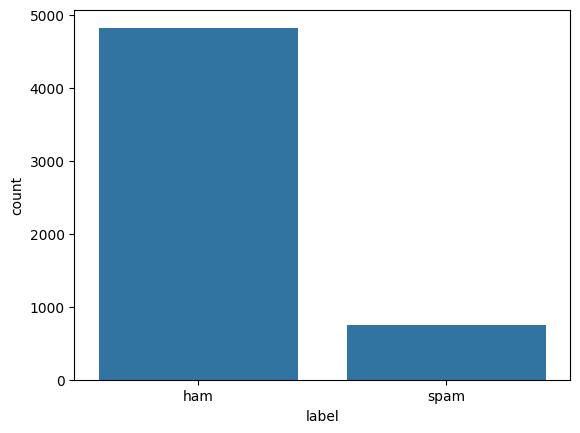

In [14]:
sns.countplot(
    x = 'label',
    data = df
)
plt.show()

In [27]:
import string
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

def clean_text(text):
  text = text.lower()
  tokens = word_tokenize(text)
  words = []
  for word in tokens:
    if word.isalnum():
      if word not in stopwords.words('english'):
        words.append(word)
  return " ".join(words)

In [26]:
df['clean_message'] = df['message'].apply(clean_text)
df[['message','clean_message']].head()

,message,clean_message
0,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry 2 wkly comp win fa cup final tkts 2...
3,U dun say so early hor... U c already then say...,u dun say early hor u c already say
4,"Nah I don't think he goes to usf, he lives aro...",nah think goes usf lives around though


In [28]:
df['label'] = df['label'].map({
    'ham':0,
    'spam':1
})

In [30]:
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(df['clean_message'])
y = df['label']

In [34]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [35]:
model = MultinomialNB()
model.fit(X_train, y_train)

MultinomialNB()

In [36]:
y_pred = model.predict(
    X_test
)

In [37]:
accuracy_score(
    y_test,
    y_pred
)

0.9730941704035875

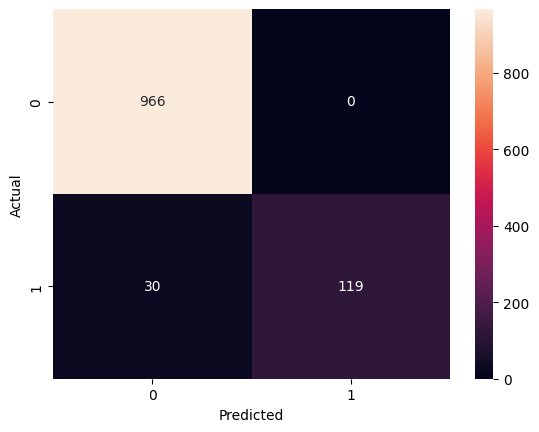

In [39]:
cm = confusion_matrix(
    y_test,
    y_pred
)
sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [40]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.97      1.00      0.98       966
           1       1.00      0.80      0.89       149

    accuracy                           0.97      1115
   macro avg       0.98      0.90      0.94      1115
weighted avg       0.97      0.97      0.97      1115



In [42]:
sample1 = [
    "Congratulations! You have won a free iPhone. Click now!"
]
sample_clean = [
    clean_text(sample1[0])
]
sample_vector = vectorizer.transform(sample_clean)
prediction = model.predict(sample_vector)
print(prediction)

[1]


In [43]:
sample2 = [
    "Mom, I will be home at 7 PM."
]
sample_clean = [
    clean_text(sample2[0])
]
sample_vector = vectorizer.transform(sample_clean)
prediction = model.predict(sample_vector)
print(prediction)

[0]
